In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

os.environ["CUDA_LAUNCH_BLOCKING"] = "0" 
os.environ["GRB_LICENSE_FILE"] = "/usr0/home/naveenr/gurobi.lic" 
os.environ['MKL_THREADING_LAYER'] = "GNU"
import torch 

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [3]:
from concept_abstraction.training import *
from concept_abstraction.selection import *
from concept_abstraction.concept_bank import *
from concept_abstraction.env_utils import *
from concept_abstraction.environments import *
from concept_abstraction.utils import *
from concept_abstraction.environments import ConceptEnv
import sys 
import argparse
import secrets
import numpy as np 
import random 
import os
from stable_baselines3 import PPO
import pickle
import resource
import time 

In [4]:
is_jupyter = 'ipykernel' in sys.modules
is_main = __name__ == "__main__"

In [302]:
if is_main:
    seed = 42
    environment_string = "pong"
    gold_timesteps = 15_000_000
    training_timesteps = 100_000 
    num_concepts_selected = 57
    out_folder = "basic"
    method = "lp" 


In [309]:
if is_main:
    for seed in [42,43,44]:
        concept_list, processed_concepts = get_concepts(environment_string,"human_selected_binary",seed)
        num_concepts_selected = min(num_concepts_selected,len(concept_list))
        ground_truth_env, ground_truth_gym_env = get_environment(environment_string, None, seed)   
        model_name = "../../results/models/env={}_training={}_seed={}.zip".format(environment_string,gold_timesteps,seed)
        if os.path.exists(model_name):
            groundtruth_model = PPO.load(model_name)
        q_estimates_full_random = rollout_q_estimates_td(groundtruth_model,ground_truth_gym_env,concept_list)
        subset_concept, idx = lp_based_selection(ground_truth_env,concept_list,num_concepts_selected,"q_value",q_estimates_full_random,"human_selected_binary")
        print(seed,idx)
        two_stage_env, two_stage_gym_env = get_environment(environment_string,subset_concept,seed,processed_concepts=processed_concepts,concept_idx=idx)
        model = train_ppo_model(two_stage_env,environment_string,policy="MlpPolicy",total_timesteps=200_000,custom_name="{}_perfect_lp_{}".format(environment_string,seed))

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

Starting stable training for sparse rewards...
Total of 100000 steps
Step 0/100000, Loss mean: 0.0000
Step 5000/100000, Loss mean: 0.7357
Step 10000/100000, Loss mean: 0.6347
Step 15000/100000, Loss mean: 0.5930
Step 20000/100000, Loss mean: 0.6369
Updated target network at step 500, Avg recent loss: 0.6405
Step 25000/100000, Loss mean: 0.0414
Step 30000/100000, Loss mean: 0.0373
Step 35000/100000, Loss mean: 0.0359
Step 40000/100000, Loss mean: 0.0354
Updated target network at step 1000, Avg recent loss: 0.0357
Step 45000/100000, Loss mean: 0.0204
Step 50000/100000, Loss mean: 0.0201
Step 55000/100000, Loss mean: 0.0188
Step 60000/100000, Loss mean: 0.0184
Updated target network at step 1500, Avg recent loss: 0.0185
Step 65000/100000, Loss mean: 0.0152
Step 70000/100000, Loss mean: 0.0133
Step 75000/100000, Loss mean: 0.0136
Step 80000/100000, Loss mean: 0.0120
Updated target network at step 2000, Avg recent loss: 0.0121
Step 85000/100000, Loss mean: 0.0109
Step 90000/100000, Loss mea

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


KeyboardInterrupt: 

In [ ]:
if is_main:
    for seed in [42,43,44]:
        concept_list, processed_concepts = get_concepts(environment_string,"human_selected_binary",seed)
        num_concepts_selected = min(num_concepts_selected,len(concept_list))
        ground_truth_env, ground_truth_gym_env = get_environment(environment_string, None, seed)   
        model_name = "../../results/models/env={}_training={}_seed={}.zip".format(environment_string,gold_timesteps,seed)
        if os.path.exists(model_name):
            groundtruth_model = PPO.load(model_name)
        q_estimates_full_random = rollout_q_estimates_td(groundtruth_model,ground_truth_gym_env,concept_list,total_timesteps=200_000)
        subset_concept, idx = lp_based_selection(ground_truth_env,concept_list,num_concepts_selected,"q_value",q_estimates_full_random,"human_selected_binary")
        print(seed,idx)
        two_stage_env, two_stage_gym_env = get_environment(environment_string,subset_concept,seed,processed_concepts=processed_concepts,concept_idx=idx)
        model = train_ppo_model(two_stage_env,environment_string,policy="MlpPolicy",total_timesteps=200_000,custom_name="{}_perfect_lp_more_timesteps_{}".format(environment_string,seed))

In [315]:
unique_actions = list(set([int(i[1]) for i in q_estimates]))
actions = np.array([i[1] for i in q_estimates])

discretized_X = np.array([i[0] for i in q_estimates])

q_values = np.array([i[2] for i in q_estimates])

final_vals = []
seen = set()
for a in unique_actions:
    relevant_idx = np.where(actions == a)[0]
    relevant_q = q_values[relevant_idx]

    if len(relevant_idx) <= 500:
        relevant_low = relevant_high = relevant_idx
    else:
        # Sort within this action only
        sorted_within_action = np.argsort(relevant_q)
        relevant_low = relevant_idx[sorted_within_action[:500]]
        relevant_high = relevant_idx[sorted_within_action[-500:]]
    for low_idx in relevant_low:
        for high_idx in relevant_high:
            diff = abs(q_values[low_idx] - q_values[high_idx])
            # tuple of differing concept indices
            diffs = tuple(i for i, (l, h) in enumerate(zip(discretized_X[low_idx], discretized_X[high_idx])) if l != h)
            tup = (diff, diffs)
            if diffs not in seen and diffs != ():
                seen.add(diffs)
                final_vals.append(tup)

In [323]:
temp = random.sample(final_vals,50_000)

In [333]:
subset_concept, idx = lp_based_selection(ground_truth_env,concept_list,num_concepts_selected,"q_value",q_estimates_full_random,"human_selected_binary")

(2.0514065623283386, (3, 4, 6, 15, 16, 18, 27, 28, 30, 39, 40, 42, 51, 52, 54, 61, 63, 64, 66, 73, 74, 75, 76, 77, 78, 86, 87, 88, 89, 90, 98, 99, 100, 101, 102, 106, 111, 112, 114, 118, 119, 120, 123, 124, 126, 135, 136, 138, 140, 141, 147, 148, 150, 152, 153, 159, 160, 162, 163, 164, 165, 171, 172, 174, 175, 183, 184, 195, 196, 207, 208, 219, 220))


In [349]:
relevant_idx = np.where(actions == a)[0]
relevant_q = q_values[relevant_idx]

In [354]:
len(relevant_q)

100000

In [353]:
len(set([tuple(i[0]) for i in q_estimates_full_random]))

10671

In [358]:
a = [tuple(i) for i in discretized_X[relevant_idx].tolist()]

In [372]:
unique_actions = list(set([int(i[1]) for i in new_q]))
actions = np.array([i[1] for i in new_q])


discretized_X = np.array([i[0] for i in new_q])

q_values = np.array([i[2] for i in new_q])

final_vals = []
seen = set()
for a in unique_actions:
    relevant_idx = np.where(actions == a)[0]
    relevant_q = q_values[relevant_idx]
    
    if len(relevant_idx) <= 500:
        relevant_low = relevant_high = relevant_idx
    else:
        # Sort within this action only
        sorted_within_action = np.argsort(relevant_q)
        relevant_low = relevant_idx[sorted_within_action[:500]]
        relevant_high = relevant_idx[sorted_within_action[-500:]]
    for low_idx in relevant_low:
        for high_idx in relevant_high:
            diff = abs(q_values[low_idx] - q_values[high_idx])
            # tuple of differing concept indices
            diffs = tuple(i for i, (l, h) in enumerate(zip(discretized_X[low_idx], discretized_X[high_idx])) if l != h)
            tup = (diff, diffs)
            if diffs not in seen and diffs != ():
                seen.add(diffs)
                final_vals.append(tup)
# if len(final_vals) > 50_000:
#     final_vals = random.sample(final_vals,50_000)
final_vals = sorted(final_vals,reverse=True)
print(final_vals[0])
idx, num_covered = max_prefix_gurobi(final_vals,num_concepts_selected)

(2.0096279680728912, (3, 4, 15, 16, 27, 28, 39, 40, 51, 52, 61, 63, 64, 73, 74, 75, 76, 77, 82, 85, 86, 87, 88, 89, 94, 97, 98, 99, 100, 101, 106, 108, 111, 112, 118, 119, 120, 123, 124, 135, 136, 139, 140, 141, 147, 148, 151, 152, 153, 159, 160, 163, 171, 172, 175, 183, 184, 186, 195, 196, 198, 207, 208, 210, 219, 220, 222))


In [ ]:
idx, num_covered = max_prefix_gurobi(final_vals,num_concepts_selected)

In [373]:
len(final_vals)

675842

In [371]:
len(idx)

25

In [344]:
num_covered, len(final_vals)

(2704, 2704)

In [331]:
[id for id,i in enumerate(final_vals) if set(idx).intersection(set(i[1])) == set()][0]

828089

In [324]:
idx, _ = max_prefix_gurobi(temp,num_concepts_selected)

In [326]:
len(idx) 

19

In [ ]:
lp_based_selection(ground_truth_env,concept_list,num_concepts_selected,"q_value",q_estimates_full_random,"human_selected_binary")

In [319]:
final_vals = sorted(final_vals,reverse=True)

In [311]:
idx, num_concepts_selected

([118], 57)

In [308]:
q_estimates_full_random

[]

In [299]:
idx = [0, 4, 10]


approx_kl,█▅▅▅▅▄▅▄▄▄▄▄▃▂▂▁▁▁▄▄▁▁▁▂▂▂▂▃▃▃▃▃▃▂▂▂▂▂▁▂
clip_fraction,███▄▄▄▄▄▃▃▃▃▃▃▃▄▂▂▂▁▃▁▁▁▂▂▂▃▃▃▄▂▂▂▃▁▁▃▃▃
ema_norm_reward,▁▁▁▁▂▃▃▄▄▄▄▄▅▅▄▄▅▅▆▄▅▆▅▆▆▅▅▅▆▇▆▇███▇▇▇▇▆
entropy_loss,▁▁▂▂▃▃▄▅▅▅▆▅▅▅▆▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇██████████
episode_length_mean,▁▁▁▃▁▂▁▁▂▁▂▁▁▂▃▂▃▃▂▂▂▄▂▅▄▅▁▄▅▅▇▃▄▃▃▃▅█▄▃
episode_reward_max,▁▃▂▂▁▂▂▁▁▂▂▃▃▃▂▃▃▃▂▄▂▃▂▂▃▃▅▄▂▃▅▅▅█▅▆▃▆▃▅
episode_reward_mean,▁▁▁▁▄▂▃▄▁▃▃▃▃▂▂▆▆▂▅▄▃▆▆▅▆▆▃▅▅▃▅▅▃▄▅██▅▃▄
episode_reward_min,▁▁▁▂▂▂▂▃▃▃▃▅▂▃▃▂▅▇▆▂▄▆▅▁▃█▄▆▅▄▃▆▇▄█▅▃▂▃▅
episodes_completed,▁▁▁▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇█████
explained_variance,█▄▁▁▁▃▃▃▃▂▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇
+1,...


In [215]:
len(set(all_state_actions_2)), len(all_state_actions_total)

(196, 4096)

In [138]:
td_learner_1, all_state_actions_1 = rollout_q_estimates_td(groundtruth_model,ground_truth_gym_env,concept_list,get_td_learner=True)
td_learner_2, all_state_actions_2 = rollout_q_estimates_td(groundtruth_model,ground_truth_gym_env,concept_list,get_td_learner=True)


Starting stable training for sparse rewards...
Total of 100000 steps
Step 0/100000, Loss mean: 0.0000
Episode 25, Avg Reward: 98.08, Loss (mean/std/max): 0.49/0.35/1.20, Epsilon: 0.096
Step 5000/100000, Loss mean: 0.1964
Episode 50, Avg Reward: 124.92, Loss (mean/std/max): 0.07/0.06/0.30, Epsilon: 0.093
Episode 75, Avg Reward: 101.16, Loss (mean/std/max): 0.03/0.01/0.06, Epsilon: 0.090
Step 10000/100000, Loss mean: 0.0235
Episode 100, Avg Reward: 133.16, Loss (mean/std/max): 0.02/0.01/0.04, Epsilon: 0.086
Step 15000/100000, Loss mean: 0.0180
Episode 125, Avg Reward: 119.60, Loss (mean/std/max): 0.02/0.01/0.04, Epsilon: 0.083
Episode 150, Avg Reward: 139.84, Loss (mean/std/max): 0.02/0.01/0.04, Epsilon: 0.079
Step 20000/100000, Loss mean: 0.0138
Updated target network at step 500, Avg recent loss: 0.0138
Step 25000/100000, Loss mean: 0.0418
Episode 175, Avg Reward: 370.52, Loss (mean/std/max): 0.02/0.01/0.08, Epsilon: 0.070
Step 30000/100000, Loss mean: 0.0153
Step 35000/100000, Loss me

In [160]:
steps = 0
total_timesteps = 100_000
obs, infos = ground_truth_gym_env.reset()
concepts = np.zeros((8, 12))
for i in range(8):
    # correct selection of observation
    info_i = infos[i] if infos and len(infos) > i else {}

    # use obs[i] by default; override if info has 'observation'
    raw_obs = info_i.get("observation", obs[i])
    
    # compute concepts
    concept_values = []
    for c in concept_list:
            concept_values.append(c(raw_obs))
    concepts[i] = concept_values 
all_state_actions_deterministic = []
while steps < total_timesteps:
    actions = groundtruth_model.predict(obs)[0]
    use_random = False 
    if use_random:
        actions = [ground_truth_gym_env.action_space.sample() for i in range(8)]
    for i in range(8):
        all_state_actions_deterministic.append((tuple(concepts[i])))
    next_obs, rewards, terms, truncs, infos = ground_truth_gym_env.step(actions)
    dones = np.logical_or(terms, truncs)

    # # Compute next concepts for all environments
    next_concepts = np.zeros_like(concepts)
    for i in range(8):
        # correct selection of observation
        info_i = infos[i] if infos and len(infos) > i else {}

        # use obs[i] by default; override if info has 'observation'
        raw_obs = info_i.get("observation", next_obs[i])

        # compute concepts
        concept_values = []
        for c in concept_list:
                concept_values.append(c(raw_obs))
        next_concepts[i] = concept_values 
    obs = next_obs
    concepts = next_concepts
    steps += 8 

In [183]:
steps = 0
total_timesteps = 100_000
obs, infos = ground_truth_gym_env.reset()
concepts = np.zeros((8, 12))
for i in range(8):
    # correct selection of observation
    info_i = infos[i] if infos and len(infos) > i else {}

    # use obs[i] by default; override if info has 'observation'
    raw_obs = info_i.get("observation", obs[i])
    
    # compute concepts
    concept_values = []
    for c in concept_list:
            concept_values.append(c(raw_obs))
    concepts[i] = concept_values 
all_state_actions_random = []
while steps < total_timesteps:
    actions = groundtruth_model.predict(obs)[0]
    use_random = np.random.random() < 0.3
    if use_random:
        actions = [ground_truth_gym_env.action_space.sample() for i in range(8)]
    for i in range(8):
        all_state_actions_random.append((tuple(concepts[i])))
    next_obs, rewards, terms, truncs, infos = ground_truth_gym_env.step(actions)
    dones = np.logical_or(terms, truncs)

    # # Compute next concepts for all environments
    next_concepts = np.zeros_like(concepts)
    for i in range(8):
        # correct selection of observation
        info_i = infos[i] if infos and len(infos) > i else {}

        # use obs[i] by default; override if info has 'observation'
        raw_obs = info_i.get("observation", next_obs[i])

        # compute concepts
        concept_values = []
        for c in concept_list:
                concept_values.append(c(raw_obs))
        next_concepts[i] = concept_values 
    obs = next_obs
    concepts = next_concepts
    steps += 8 

In [208]:
q_estimate_list = []
for state_tuple in all_state_actions_total:
    state_array = np.array(state_tuple)
    for action in [0,1]:
        q_value = td_learner_1.get_q_value(state_array, action)
        q_estimate_list.append((state_array, action, q_value))

In [291]:
unique_actions = list(set([int(i[1]) for i in differences]))
actions = np.array([i[1] for i in differences])
discretized_X = np.array([i[0] for i in differences])
q_values = np.array([i[2] for i in differences])

final_vals = []
seen = set()
for a in unique_actions:
    relevant_idx = np.where(actions == a)[0]
    relevant_q = q_values[relevant_idx]
    
    if len(relevant_idx) <= 500:
        relevant_low = relevant_high = relevant_idx
    else:
        # Sort within this action only
        sorted_within_action = np.argsort(relevant_q)
        relevant_low = relevant_idx[sorted_within_action[:500]]
        relevant_high = relevant_idx[sorted_within_action[-500:]]
    for low_idx in relevant_low:
        for high_idx in relevant_high:
            diff = abs(q_values[low_idx] - q_values[high_idx])
            # tuple of differing concept indices
            diffs = tuple(i for i, (l, h) in enumerate(zip(discretized_X[low_idx], discretized_X[high_idx])) if l != h)
            tup = (diff, diffs)
            if diffs not in seen and diffs != ():
                seen.add(diffs)
                final_vals.append(tup)
final_vals = sorted(final_vals,reverse=True)

In [290]:
differences = []
for i in range(0,len(q_estimates_full_random),2):
    differences.append((q_estimates_full_random[i][0],0,q_estimates_full_random[i][2]-q_estimates_full_random[i+1][2])) 

In [292]:
max_prefix_gurobi(final_vals,3)

([1, 2, 5], 87)

In [272]:
q_estimates_full_random[0], q_estimates_full_random[7832]

((array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), 0, 2.7569239139556885),
 (array([1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0]), 0, 6.7570672035217285))

In [265]:
final_vals[0]

(4.934476613998413, (0, 1, 2, 3, 5, 8, 9, 10, 11))

In [ ]:
final_vals 

In [271]:
for i in final_vals:
    if 5 in i[1] and 4 not in i[1] and 10 not in i[1] and 7 not in i[1]:
        print(5,i)
    if 7 in i[1] and 10 not in i[1] and 4 not in i[1] and 5 not in i[1]:
        print(4,i)

5 (4.068265199661255, (0, 1, 2, 3, 5, 8, 11), 0, 7826)
5 (4.00014328956604, (0, 1, 2, 3, 5, 8, 9), 0, 7832)
5 (3.9737308025360107, (0, 1, 2, 3, 5, 8, 9, 11), 0, 7834)
5 (3.9214465618133545, (0, 1, 2, 3, 5, 8), 0, 7824)
5 (3.9157750606536865, (0, 1, 2, 3, 5, 6, 8, 9, 11), 0, 7898)
5 (3.8842132091522217, (0, 1, 3, 5, 8, 9, 11), 0, 6810)
5 (3.879987955093384, (1, 2, 3, 5, 6, 8), 0, 3792)
5 (3.8774306774139404, (1, 2, 3, 5, 8, 11), 0, 3730)
5 (3.856966733932495, (1, 2, 3, 5, 8), 0, 3728)
5 (3.8338968753814697, (1, 2, 3, 5, 6, 8, 11), 0, 3794)
5 (3.8276002407073975, (1, 2, 3, 5, 8, 9), 0, 3736)
5 (3.8261220455169678, (0, 1, 2, 3, 5, 6, 8, 11), 0, 7890)
5 (3.8240602016448975, (1, 2, 3, 5, 8, 9, 11), 0, 3738)
5 (3.815107583999634, (2, 3, 5, 6, 8, 11), 0, 1746)
5 (3.7981603145599365, (0, 2, 3, 5, 8, 9, 11), 0, 5786)
5 (3.789998769760132, (0, 2, 3, 5, 6, 8, 9, 11), 0, 5850)
5 (3.7804930210113525, (0, 1, 3, 5, 8, 9), 0, 6808)
5 (3.7783172130584717, (0, 3, 5, 8, 9, 11), 0, 4762)
5 (3.776861906051

In [293]:
idx = [1,2,5]
two_stage_env, two_stage_gym_env = get_environment(environment_string,subset_concept,seed,processed_concepts=processed_concepts,concept_idx=idx)
model = train_ppo_model(two_stage_env,environment_string,policy="MlpPolicy",total_timesteps=100_000,custom_name="{}_perfect_lp_{}".format(environment_string,1))

approx_kl,████▄▂▅▅▅▆▇▆▆▆▆▃▃▅▃▇▇▅▃▃▃▃▃▁▁▁▃▃▃▃▄▂▂▂▂▂
clip_fraction,▅▅▁▁▁█▂▂▂▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▃▁▁▂▂▁▃▂▂▁▁▂▂▂▂▁
ema_norm_reward,▁▁▃▁▃▅▅▃▅▅▅█▅▆▆▄▅▄▇▇▆▄█▇▆█▆█▄▆█▇█▆█▇▇▆▇▆
entropy_loss,▁▁▁▁▁▃▃▄▅▅▅▅▅▅▅▆▇▇▆▆▇▇▇▇██████▇▇████▇▇▇▇
episode_length_mean,▂▂▂▁▃▃▃▁▄▅▄▃▄▅▃█▇▃▄▄▂▅▅▅▅▄▄▆▅▄▅▅▅▅▃▅▂▃▅▇
episode_reward_max,▂▅▄▂▃▁▂▂▂▃▄▃▃▃▃▃▁▃█▃▄▂▂▃▂▃▄▂▃▂█▂▄▅▃▂▃▃▆▃
episode_reward_mean,▁▁▂▃▁▁▂▃▃▆▃▂▄█▅▄▃▅▅▆▃▃▅▅▄▄▃▄▄▄▅▄▇▄▃▃▃▃▂▃
episode_reward_min,▂▁▂▂▂▄▅▃▁▂▂▅▃▃▅▄▃▅▃▄▄▂▄▃▃▄▃▅▄█▄▂▂▃▄▃▅▃▅▂
episodes_completed,▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇██████
explained_variance,▅▅▅███▁▄▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅
+1,...


In [261]:
idx = [4,7,10]
two_stage_env, two_stage_gym_env = get_environment(environment_string,subset_concept,seed,processed_concepts=processed_concepts,concept_idx=idx)
model = train_ppo_model(two_stage_env,environment_string,policy="MlpPolicy",total_timesteps=100_000,custom_name="{}_perfect_lp_{}".format(environment_string,1))

approx_kl,██▅▅▅▂▂▃▃▃▄▁▂▁▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▃▃▃▂▂▂▂▄
clip_fraction,████▃▃▃▃▂▂▂▁▁▃▁▁▁▁▁▁▁▁▁▁▂▂▂▁▁▂▂▂▂▂▂▂▂▃▃▃
ema_norm_reward,▁▁▁▁▁▁▁▁▁▁▁▂▂▂▂▂▃▂▂▂▂▂▂▂▂▃▄▄▃▆▅▅▅█▇▇▆▇▇▆
entropy_loss,▁▁▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇███▇▇▇▇▇▇▇▇▇▇
episode_length_mean,▁▁▁▁▁▁▁▁▁▂▁▁▂▂▂▃▂▂▂▂▂▂▅▅▆▃▆▆▁███▆▂█▅▆▇▇▅
episode_reward_max,▁▁▁▂▁▁▁▁▁▁▁▁▃▃▁▂▁▃▁▁▂▄▂▄▂▅▇▄█▅▅▆▆█▅▅█▇▅▅
episode_reward_mean,▁▁▁▁▁▁▁▁▁▁▂▁▁▁▃▁▁▂▂▁▂▂▃▃▄▂██▅▃▆▇▄▅▆▄▄▅▆▄
episode_reward_min,▁▁▁▁▁▁▁▁▁▁▁▂▂▂▂▁▂▂▂▄▁▄█▅▆▅▄▅▆▃▇▇▆▆▆▃▅▅▆▄
episodes_completed,▁▂▂▂▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇█████
explained_variance,██▂▁▁▃████▇▇▇▇█▇▇███▇███████████████████
+1,...


In [204]:
for num,i in enumerate(final_vals):
    if 5 in i[1] and 4 not in i[1] and 10 not in i[1] and 11 not in i[1]:
        print("5",i,num)
    if 11 in i[1] and 4 not in i[1] and 10 not in i[1] and 5 not in i[1]:
        print("11",i,num)

1 (1.079519271850586, (0, 1, 5, 6, 7)) 383
11 (1.0031089782714844, (1, 6, 11)) 391
11 (0.9173884391784668, (0, 6, 7, 11)) 406
11 (0.8735718727111816, (0, 1, 3, 11)) 416
11 (0.7594308853149414, (6, 11)) 448
11 (0.7086491584777832, (0, 7, 11)) 463
1 (0.6189494132995605, (0, 5, 6, 7, 9)) 506
1 (0.5629782676696777, (0, 5, 7)) 541
11 (0.5573868751525879, (0, 11)) 545
11 (0.4420485496520996, (0, 1, 3, 7, 11)) 644
11 (0.41704320907592773, (0, 2, 3, 7, 11)) 668
1 (0.40789175033569336, (0, 5)) 677
1 (0.3612818717956543, (0, 1, 5, 7, 9)) 719
11 (0.3582015037536621, (0, 2, 3, 11)) 723
11 (0.34078121185302734, (0, 6, 11)) 751
1 (0.3372931480407715, (1, 5, 7, 9)) 757
1 (0.3304257392883301, (5, 7, 9)) 769
1 (0.3268594741821289, (5, 6, 7, 9)) 779
1 (0.3154940605163574, (0, 1, 5, 6, 7, 9)) 799
1 (0.29781627655029297, (5, 7, 8, 9)) 842
1 (0.29349613189697266, (5, 6, 7, 8, 9)) 857
1 (0.2860598564147949, (0, 1, 5, 9)) 873
1 (0.2720985412597656, (1, 5, 6, 7, 9)) 904
11 (0.25795459747314453, (1, 3, 6, 11))

In [205]:
subset_concept, idx_1 = lp_based_selection(ground_truth_env,concept_list,num_concepts_selected,"q_value",q_estimates_1,"human_selected_binary")
print(idx_1)
two_stage_env, two_stage_gym_env = get_environment(environment_string,subset_concept,seed,processed_concepts=processed_concepts,concept_idx=idx_1)
model = train_ppo_model(two_stage_env,environment_string,policy="MlpPolicy",total_timesteps=100_000,custom_name="{}_perfect_lp_{}".format(environment_string,1))

(4.732990741729736, (0, 1, 4, 5, 7, 11))
[4, 10, 11]


approx_kl,█▆▄▂▂▂▃▂▂▃▂▂▄▃▂▂▃▂▂▃▂▂▂▂▃▁▁▂▂▁▁▂▂▂▃▃▄▂▂▂
clip_fraction,████▃▃▃▂▂▂▂▃▂▂▂▂▁▃▃▃▁▃▂▂▃▃▁▃▃▃▁▃▂▂▂▅▂▂▂▂
ema_norm_reward,▁▂▁▂▂▃▃▄▄▄▄▄▆██▅▅▄▅▅▇▅▆▅▅▆▅▇▇▇▆▇▆▆▆▆▇▇▇▆
entropy_loss,▁▃▃▄▄▄▄▅▅▅▆▆▆▆▆▇▇▇██▇▇▇▇▇████▇▇▇██▇▇▇▇▇▇
episode_length_mean,▁▁▂▂▂▃▃▄▄▃▂▃█▁▃▄▄▅▄▄▅▆▁▄▄▄▂▂▄▄▅▄▄▄▃▃▄▁▆▃
episode_reward_max,▁▃▃▁▁▂▂▄▅▃▇▆▅▄▂▇▅▆▁▆▅▄▇▄█▄▂▆▅▄▄▅▄▄▃▇▄▄▄▄
episode_reward_mean,▁▁▁▁▂▁▂▂▂▃▃▃▄▃▃▃▄▄█▂▃▃▄▆▄▂▄▅▄▂▃▃▄▄▃▄▄▄▃▄
episode_reward_min,▁▁▂▁▂▁▂▂▃▂▇▂▄▂▂▆▃▂▄▄▂▄▃▃▃▃▂▃▇▃▃▅▃█▂▄▃▅▄▆
episodes_completed,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇███
explained_variance,▂▂▁▃▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▇▇▇▇███▇█████▇▇▇▇█
+1,...


In [206]:
subset_concept, idx_2 = lp_based_selection(ground_truth_env,concept_list,num_concepts_selected,"q_value",q_estimates_2,"human_selected_binary")
print(idx_2)
two_stage_env, two_stage_gym_env = get_environment(environment_string,subset_concept,seed,processed_concepts=processed_concepts,concept_idx=idx_2)
model = train_ppo_model(two_stage_env,environment_string,policy="MlpPolicy",total_timesteps=100_000,custom_name="{}_perfect_lp_{}".format(environment_string,2))

(4.551967620849609, (1, 4, 5, 7, 9, 10, 11))
[4, 5, 10]


approx_kl,█████▇▅▃▂▃▂▄▂▂▃▅▃▁██▄▁▁▄▄▆▆▂▄▃▁▁▁▄▃▂▂▁▁▂
clip_fraction,█▄▂▃▃▄▃▃▃▃▅▅▁▁▁▂▂▄▂▂▂▂▃▂▂▁▄▃▃▃▂▂▂▅▅▁▁▄▁▁
ema_norm_reward,▁▁▂▂▂▄▃▃▄▅▄▄▄▅▄▅▅▆▆▆▆▆▇▇▇▇▆▆▆▆▆▇▆▆▆▆▆▇█▇
entropy_loss,▁▁▂▃▃▅▅▆▅▅▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇████▇█▇█▇▇▇▇
episode_length_mean,▁▂▁▃▂▃▂▃▄▃▂▃▃▁█▃▄▅▅▄▄▅▄▃▄▄▄▄▁▄▄▂▄▄▅▃▆▄▅▃
episode_reward_max,▂▂▃▁▂▂▁▃▃▂▂▁▁▃▂▄█▄▃▃▄▄▃▆▃▄▃▅▃█▄▂▃▅▃▃▂▄▃▅
episode_reward_mean,▁▁▁▃▂▂▂▂▃▂▁▄▅▂▄▃▆▄▄█▅▃▃▅▄▃▃▅▄▄▄▆▃▄▃▄▃▅▅▆
episode_reward_min,▂▂▂▁▃▆▃▂▃▂▃▃▄▄▅▆▃▇▄▅▅▄▄▅▇▅▅▃▃▇▆█▅█▆▅▄█▅▃
episodes_completed,▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇█████
explained_variance,█▃▁▆▆███████████████████████████████████
+1,...


In [207]:
subset_concept, idx_3 = lp_based_selection(ground_truth_env,concept_list,num_concepts_selected,"q_value",q_estimates_3,"human_selected_binary")
print(idx_3)
two_stage_env, two_stage_gym_env = get_environment(environment_string,subset_concept,seed,processed_concepts=processed_concepts,concept_idx=idx_3)
model = train_ppo_model(two_stage_env,environment_string,policy="MlpPolicy",total_timesteps=250_000,custom_name="{}_perfect_lp_{}".format(environment_string,3))

(4.5372772216796875, (0, 1, 4, 5, 7, 11))
[4, 10, 11]


approx_kl,▅▄██▃▃▄▂▅▃▃▄▄▄▃▃▅▄▃▃▃▃▅▂▃▅▄▁▁▃▄▄▂▃▅▃▄▄▁▁
clip_fraction,▃▃▅▅▂▂▂▆▆▆▅▂▂▃▆▄█▄▄▄▇▄▁▁▄▃▃▂▄▅▁▂▁▄▆▅▅▅▃▅
ema_norm_reward,▁▁▁▂▁▂▂▂▃▃▄▅▅▆▅▅▅▅▆▇▆▇▅▆▇▆▇▆█▅▇▆▇▇▇▇▆▆▆▇
entropy_loss,▁▃▃▄▄▄▆▆▆▆▇▆▆▆▇▆▆▆▇▇▇▇▇▇▇▇▇▇█▇██▇▇▇████▇
episode_length_mean,▁▁▁▁▂▂▂▃▂▄▄▂▂▃▂▄▂▅▄▂▄▄▄▃▃▂▂▄▂▄█▂▂▃▁▄▃▃▃▄
episode_reward_max,▂▃▃▂▂▂▆▂▂▂▂▇▄▃▄█▃▄▅▃▇▄▄▅▆▄▁▄▄▆▆▄▃▅▇▆▅▄▄▅
episode_reward_mean,▁▁▃▂▂▂▃▃▃▃▄▆▆▂▅▃▆▄▆▄▄▆▅█▁▃▃▃▃▅▄▄▅▃▃▄▇▅▁▆
episode_reward_min,▁▁▁▁▁▂▂▂▂▄▃▇▁▅▂▁▄█▅▃▃▂▃▇▃▄▃▂▄▄▆▅▂▃▄▅▄▄▆▅
episodes_completed,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇█
explained_variance,▁▃▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▅▅▅▅▇▇█▇██▇▇▇█
+1,...


In [81]:
subset_concept, idx = lp_based_selection(ground_truth_env,concept_list,num_concepts_selected,"q_value",q_estimates_1,"human_selected_binary")


(2.4616838097572327, (0, 1, 4, 5, 7, 9, 10, 11))


approx_kl,█▆▆▆▆▅▅▅▁▁▂▂▂▂▂▂▂▂▂▃▂▂▂▂▂▂▂▁▁▁▁▂▂▁▁▁▂▂▂▂
clip_fraction,█▆▆▆▆▃▃▃▃▃▁▁▂▂▃▂▂▂▂▂▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▃▁▁▃▃
ema_norm_reward,▂▁▁▁▁▂▁▂▂▂▂▂▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▅▅▄▇▅█▇▆▇▇▆▆▆
entropy_loss,▁▁▁▂▂▃▄▄▄▄▅▅▅▆▆▆▆▅▅▅▆▆▇▇▇▇██▇███████████
episode_length_mean,▁▁▂▁▁▁▂▂▂▃▃▃▃▄▃▂▃▂▃▃▅▄▅█▆▂▇▃▅▂▁▅▆▃▇▂▆▆▂▃
episode_reward_max,▁▁▂▂▁▂▁▂▂▂▂▄▂▂▂▂▃▂▂▃▁▄▆▃▄▂▃▇█▄▆▃▄▄▄▄▁▁▄▂
episode_reward_mean,▁▂▂▁▂▂▂▁▂▂▂▂▂▃▂▂▂▄▄▄▃▃▃▅▆▄▁▃▄▆█▅▁▃▃▃▆▆▁▄
episode_reward_min,▂▁▁▁▁▁▂▁▂▁▂▃▃▄▂▄▄▃▃▂▃▄▄▂▃▂▇▆▃▄▄▆▄▃█▅▁▂█▄
episodes_completed,▁▁▁▁▁▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇█████
explained_variance,▂▂▁▁▁▁▁▄▄▄▄▇▇▆▆▆▇▇▇▇▇██▄▄▄▄▄▅▅▄▄▆▅▅▅▄▄▇▇
+1,...


In [145]:
subset_concept, idx_2 = lp_based_selection(ground_truth_env,concept_list,num_concepts_selected,"q_value",q_estimates_2,"human_selected_binary")
idx_2 

(4.463077068328857, (0, 1, 4, 5, 7, 9, 10, 11))


[3, 10, 11]

In [82]:
subset_concept, idx = lp_based_selection(ground_truth_env,concept_list,num_concepts_selected,"q_value",q_estimates_2,"human_selected_binary")
two_stage_env, two_stage_gym_env = get_environment(environment_string,subset_concept,seed,processed_concepts=processed_concepts,concept_idx=idx)
model = train_ppo_model(two_stage_env,environment_string,policy="MlpPolicy",total_timesteps=100_000,custom_name="{}_perfect_lp_{}".format(environment_string,2))

(1.0499188899993896, (0, 1, 4, 6, 9, 10, 11))


approx_kl,██▆▄▃▅▅▅▅▃▃▃▃▁▁▅▅▆▁▁▆▆▆▃▃▄▃▃▃▃▄▄▂▂▂▁▂▄▄▁
clip_fraction,████▅▂▂▂▂▁▂▃▃▁▁▁▁▁▁▁▁▁▆▆▂▂▂▃▃▃▂▂▁▁▃▃▃▃▃▃
ema_norm_reward,▁▁▁▁▁▁▁▁▁▁▂▂▂▃▃▃▃▃▃▃▃▅▄▄▄▅▅▆▅▇▇▇▇██▇▆▆▇▆
entropy_loss,▁▁▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇██
episode_length_mean,▁▁▁▁▁▂▁▁▂▂▁▃▃▂▂▂▃▃▄▄▃▄▅▃▄▆▃▃▃▅▅▅█▃▆▆▄▅▅▆
episode_reward_max,▁▁▁▁▁▂▂▁▁▁▁▂▂▂▂▂▂▃▄▂▅▃▂▃▂▃▄▃▄▃▅▅▄▅▃▅▃█▄▄
episode_reward_mean,▁▁▁▂▂▁▁▂▂▁▂▂▃▂▁▂▂▂▂▂▃▂▅▄▄▄▂▆▄▃▆▅▄▅▄█▆▇▅█
episode_reward_min,▁▁▁▂▂▁▁▁▂▂▂▁▃▂▂▂▁▄▅▂▄▄▂▃█▅▅▅▅▇▅▅▅▆▇▅▅▄█▇
episodes_completed,▁▁▁▂▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇█████
explained_variance,▅▅▅▁▁▁▆▆▃▃▆▆▇▇▇▇▇▆▆████▇▇▆▆▅▅▄▅▅▅▅▅▅▆▆▄▄
+1,...


In [87]:
for min_count in [1,2,5,10,25,50]:
    q_estimates = []
    for state_tuple,count in sorted_counts:
        if count >= min_count:
            state_array = np.array(state_tuple)
            for action in [0,1]:
                q_value = td_learner.get_q_value(state_array, action)
                q_estimates.append((state_array, action, q_value))
    subset_concept, idx = lp_based_selection(ground_truth_env,concept_list,num_concepts_selected,"q_value",q_estimates,"human_selected_binary")
    print(min_count,idx)
    two_stage_env, two_stage_gym_env = get_environment(environment_string,subset_concept,seed,processed_concepts=processed_concepts,concept_idx=idx)
    model = train_ppo_model(two_stage_env,environment_string,policy="MlpPolicy",total_timesteps=100_000,custom_name="{}_perfect_lp_{}".format(environment_string,min_count))    


1 [4, 5, 9]


approx_kl,██▅▄▄▃▃▃▃▃▂▂▂▂▃▂▂▂▃▃▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂
clip_fraction,███▄▄▄▂▂▂▂▂▂▂▃▃▃▃▃▂▂▁▁▂▂▂▃▃▃▃▂▂▂▃▂▂▅▅▅▁▁
ema_norm_reward,▁▁▁▂▂▂▂▂▂▂▄▃▄▄▄▄▄▄▄▅█▇▆▆▆█▇▇▇▇▇▇██▆▇▆▆█▇
entropy_loss,▁▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▇▇▇▇▇▇▇▇▇█▇▇▇▇█████
episode_length_mean,▁▁▁▁▁▁▁▂▁▁▂▂▁▂▃▂▂▂▂▂▂▃▃▃▄▃▃▃▆▃▄▃▃█▄▂▃▄▂▄
episode_reward_max,▂▂▂▃▂▂▂▂▂▃▂▂▂▃▃▃▃▄▆▂▂▁▃▅▄▅▇▃▅▆▂▆▃█▃▆▄▄▃▆
episode_reward_mean,▁▁▂▂▁▁▂▂▃▃▁▁▂▁█▁▄▃▃▄▆▅▄▅▂▄▃▄▃▅▄▃▆▅▅▃▃▅▃▇
episode_reward_min,▁▁▁▁▁▁▁▁▁▂▂▂▂▂▆▂▃▄▃▆▄▂▃▃▄▅▅▃▄█▄▂▃▅▃▅▆▂▃▄
episodes_completed,▁▁▂▂▂▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇████
explained_variance,▁▁▁▃▃▆▆▆███████▂▂▄▂▂▄▄▃▃▃▃▃▅▅▅▆▃▅▃▃▆▆▆▆▇
+1,...


2 [4, 5, 9]


approx_kl,█▅▅▅▅▃▂▄▄▃▄▄▄▂▂▂▃▃▁▁▃▃▅▅▅▁▁▁▃▄▃▃▃▃▃▂▂▂▃▃
clip_fraction,██▃▃▃▃▃▂▂▂▁▄▄▄▄▂▂▂▂▂▂▂▂▂▂▁▁▁▂▄▂▂▂▂▂▂▂▂▂▂
ema_norm_reward,▁▁▁▁▁▂▂▂▃▂▂▂▂▃▂▂▃▃▄▃▅▄▄▆▆▅▅▅▅▅▇▆▅▆▇██▇▆▇
entropy_loss,▁▁▂▂▂▄▄▄▄▄▅▅▅▆▆▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇██████████
episode_length_mean,▂▂▁▁▂▂▂▁▃▃▂▂▂▃▃▃▄▂▄▃▅▅▆█▃▅▄▅▇▂▇▄▄▆▆▅▄▇▆▁
episode_reward_max,▁▁▂▂▂▃▂▂▂▂▂▃▂▃▄▂▃▄▃▃▂▆▃▃▃▄▁▃▆▅▅▂▁▅▃▄▅▁▅█
episode_reward_mean,▂▂▁▁▁▂▁▂▂▂▂▃▃▄▄▄▃▄▆▇▄▆▃▆▇▅▆▄▆▇▆▄▆▅█▆▄▂▅▇
episode_reward_min,▁▁▁▁▁▂▂▁▁▂▂▁▂▁▂▂▅▃▁▁▂▃▁▅▃▅▃▂▄▃▆▄█▃▃▂▆▆▅▄
episodes_completed,▁▂▂▃▃▄▄▄▄▅▅▅▅▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇█████
explained_variance,▁▁▁▁▃▄▄▆▆▆██▇▇▇▇▆▆▆▆▄▄▄▄▄▃▃▅▅▅▅▄▄▃▅▄▆▅▅▅
+1,...


5 [3, 9, 10]


approx_kl,███▆▄▄▄▃▃▂▂▂▂▂▄▅▂▄▁▄▃▃▁▁▁▁▃▃▃▃▃▂▂▂▂▁▂▂▃▃
clip_fraction,██▄▄▄▄▄▃▃▁▁▁▁▁▁▂▂▂▂▂▃▃▁▁▄▄▂▂▂▂▂▃▂▂▂▃▃▂▂▂
ema_norm_reward,▁▁▁▁▁▁▁▁▂▂▂▂▂▂▂▃▃▄▄▄▅▄▅▅▆▇▇▇▅▅▆▆▇▇▇█▇▇██
entropy_loss,▁▁▂▂▂▂▃▃▃▃▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇████████
episode_length_mean,▁▁▁▁▁▁▁▂▂▁▄▂▃▂▂▂▂▂▂▂▂▂▂▄▃▃▄▃▃▅▃▃▇▄▄▆▅▆▅█
episode_reward_max,▁▁▂▁▂▁▂▂▂▂▂▂▁▄▃▂▂▂▃▃▆▅▄▄▃▃▇▂▅▅▆▅█▄▃▃▃▃▄▆
episode_reward_mean,▁▂▁▁▂▁▁▁▂▁▂▁▂▁▁▁▂▂▃▂▃▂▂▂▃▂▄▆▃▃▂▅▄▄▄▄▆▄▇█
episode_reward_min,▁▁▁▁▁▁▂▁▁▁▁▂▁▂▁▁▂▂▃▂▂▂▂▄▂▄▅▃▂▄▃▆▃▄█▄▇▃▅▆
episodes_completed,▁▁▂▂▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇█
explained_variance,▁▁▁▁▁▂▂▅▅█████▅▅▅▅▂▂▂▂▂▁▁▂▂▂▂▂▂▁▁▁▁▂▂▃▃▃
+1,...


10 [4, 7, 9]


wandb: ERROR Control-C detected -- Run data was not synced


KeyboardInterrupt: 

In [23]:
q_estimates_1 = rollout_q_estimates_td(groundtruth_model,ground_truth_gym_env,concept_list,total_timesteps=20_000)
q_estimates_2 = rollout_q_estimates_td(groundtruth_model,ground_truth_gym_env,concept_list,total_timesteps=20_000)

Starting stable training for sparse rewards...
Total of 20000 steps
Step 0/20000, Loss mean: 0.0000
Episode 25, Avg Reward: 92.84, Loss (mean/std/max): 0.68/0.39/1.42, Epsilon: 0.096
Step 5000/20000, Loss mean: 0.2743
Step 10000/20000, Loss mean: 0.0882
Episode 50, Avg Reward: 363.40, Loss (mean/std/max): 0.08/0.02/0.14, Epsilon: 0.086
Step 15000/20000, Loss mean: 0.0554

Final training phase...
Final training step 0/1000, Loss: 0.0774
Updated target network at step 500, Avg recent loss: 0.0553
Final training step 100/1000, Loss: 0.0141
Final training step 200/1000, Loss: 0.0084
Final training step 300/1000, Loss: 0.0028
Final training step 400/1000, Loss: 0.0058
Final training step 500/1000, Loss: 0.0033
Updated target network at step 1000, Avg recent loss: 0.0076
Final training step 600/1000, Loss: 0.0087
Final training step 700/1000, Loss: 0.0085
Final training step 800/1000, Loss: 0.0051
Final training step 900/1000, Loss: 0.0065


Training Summary
Total episodes completed: 65
Fina

In [11]:

if is_main:
    concept_list, processed_concepts = get_concepts(environment_string,"human_selected_binary",seed)
    num_concepts_selected = min(num_concepts_selected,len(concept_list))
    ground_truth_env, ground_truth_gym_env = get_environment(environment_string, None, seed)   
    model_name = "../../results/models/env={}_training={}_seed={}.zip".format(environment_string,gold_timesteps,seed)
    if os.path.exists(model_name):
        groundtruth_model = PPO.load(model_name)
    else:
        if "cyclic" in environment_string or "tree" in environment_string or "glucose" in environment_string:
            policy = "MlpPolicy"
        else:
            policy = "CnnPolicy"

        if policy == "MlpPolicy":
            groundtruth_model = train_ppo_model(ground_truth_env,environment_string+"_raw",total_timesteps=gold_timesteps,policy=policy)
        else:
            groundtruth_model = train_ppo_model(ground_truth_env,environment_string,total_timesteps=gold_timesteps,policy=policy)
        
        groundtruth_model.save(model_name)
    

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

In [12]:
model_name = "../../results/q_estimates/env={}_training={}_seed={}_selection={}_source={}.pkl".format(environment_string,gold_timesteps,seed,"q_value","human_selected_binary")
if os.path.exists(model_name):
    q_estimates = pickle.load(open(model_name,"rb"))

In [13]:
num_concepts_selected = 57

In [25]:
discretized_X = np.array([i[0] for i in q_estimates])
unique_actions = list(set([int(i[1]) for i in q_estimates]))
actions = np.array([i[1] for i in q_estimates])
q_values = np.array([i[2] for i in q_estimates])

final_vals = []
seen = set()
for a in unique_actions:
    relevant_idx = np.where(actions == a)[0]
    if len(relevant_idx) <= 500:
        relevant_low = relevant_high = relevant_idx
    else:
        relevant_low = np.argsort(np.abs(q_values))[:500]
        relevant_high = np.argsort(np.abs(q_values))[-500:]
    for low_idx in relevant_low:
        for high_idx in relevant_high:
            diff = abs(q_values[low_idx] - q_values[high_idx])
            # tuple of differing concept indices
            diffs = tuple(i for i, (l, h) in enumerate(zip(discretized_X[low_idx], discretized_X[high_idx])) if l != h)
            tup = (diff, diffs)
            if diffs not in seen and diffs != ():
                seen.add(diffs)
                final_vals.append(tup)

# if len(final_vals) > 50_000:
#     final_vals = random.sample(final_vals,50_000)

final_vals = sorted(final_vals,reverse=True)

In [24]:
final_vals[0]

(1.3655036501586437,
 (3,
  4,
  6,
  15,
  16,
  18,
  27,
  28,
  30,
  39,
  40,
  42,
  51,
  52,
  54,
  58,
  61,
  63,
  64,
  66,
  70,
  73,
  75,
  76,
  78,
  82,
  85,
  87,
  88,
  90,
  94,
  97,
  99,
  100,
  102,
  104,
  105,
  106,
  109,
  110,
  111,
  112,
  114,
  115,
  116,
  117,
  118,
  120,
  122,
  123,
  124,
  125,
  126,
  127,
  128,
  129,
  134,
  135,
  136,
  137,
  138,
  139,
  140,
  147,
  148,
  150,
  151,
  159,
  160,
  162,
  163,
  171,
  172,
  174))

In [18]:
len(final_vals)

50000

In [27]:
idx, _ = max_prefix_gurobi(final_vals,num_concepts_selected)

In [29]:
idx

[15, 61, 86]

In [45]:
model_name

'../../results/q_estimates/env=pong_training=15000000_seed=43_selection=q_value_source=human_selected_binary.pkl'

In [46]:
q_estimates = pickle.load(open(model_name,"rb"))

In [47]:
subset_concept, idx = lp_based_selection(ground_truth_env,concept_list,num_concepts_selected,"q_value",q_estimates,"human_selected_binary")

In [48]:
idx 

[4,
 6,
 39,
 50,
 61,
 65,
 73,
 74,
 84,
 86,
 96,
 99,
 101,
 106,
 110,
 119,
 122,
 123,
 124,
 131,
 132,
 141,
 150,
 151,
 153,
 163,
 175,
 222]

In [30]:
q_estimates = rollout_q_estimates_td(groundtruth_model,ground_truth_gym_env,concept_list)

Starting stable training for sparse rewards...
Total of 100000 steps
Step 0/100000, Loss mean: 0.0000
Step 5000/100000, Loss mean: 0.8599
Step 10000/100000, Loss mean: 0.9120
Step 15000/100000, Loss mean: 0.8716
Step 20000/100000, Loss mean: 0.9107
Updated target network at step 500, Avg recent loss: 0.9274
Step 25000/100000, Loss mean: 0.0478
Step 30000/100000, Loss mean: 0.0487
Step 35000/100000, Loss mean: 0.0439
Step 40000/100000, Loss mean: 0.0436
Updated target network at step 1000, Avg recent loss: 0.0434
Step 45000/100000, Loss mean: 0.0231
Step 50000/100000, Loss mean: 0.0217
Step 55000/100000, Loss mean: 0.0204
Step 60000/100000, Loss mean: 0.0207
Updated target network at step 1500, Avg recent loss: 0.0205
Step 65000/100000, Loss mean: 0.0167
Step 70000/100000, Loss mean: 0.0146
Step 75000/100000, Loss mean: 0.0131
Step 80000/100000, Loss mean: 0.0131
Updated target network at step 2000, Avg recent loss: 0.0131
Step 85000/100000, Loss mean: 0.0125
Step 90000/100000, Loss mea

In [38]:
len(idx), num_concepts_selected, len(q_estimates)

(29, 57, 19163)

In [44]:
model_name = "../../results/q_estimates/env={}_training={}_seed={}_selection={}_source={}.pkl".format(environment_string,gold_timesteps,43,"q_value","human_selected_binary")
pickle.dump(q_estimates,open(model_name,"wb"))

In [50]:
len(idx)

28

In [32]:
two_stage_env, two_stage_gym_env = get_environment(environment_string,subset_concept,seed,processed_concepts=processed_concepts,concept_idx=idx)
model = train_ppo_model(two_stage_env,environment_string,policy="MlpPolicy",total_timesteps=training_timesteps,custom_name="{}_perfect_lp_{}".format(environment_string,seed))    
lp_two_stage_reward = evaluate_model(environment_string,two_stage_gym_env,model,seed)

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
wandb: Currently logged in as: naveenr (naveenr-carnegie-mellon-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


KeyboardInterrupt: 

In [39]:
ground_truth_env, ground_truth_gym_env = get_environment(environment_string, None, seed)   

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

In [53]:
environment_string = "cart_pole"
seed = 43
ground_truth_env, ground_truth_gym_env = get_environment(environment_string, None, seed)   
concept_list, processed_concepts = get_concepts(environment_string,"human_selected_binary",seed)
num_concepts_selected = len(concept_list)


/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

In [57]:
seed = 42
environment_string = "pong"
gold_timesteps = 15_000_000
ground_truth_env, ground_truth_gym_env = get_environment(environment_string, None, seed)   
model_name = "../../results/models/env={}_training={}_seed={}.zip".format(environment_string,gold_timesteps,seed)
groundtruth_model = PPO.load(model_name)

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

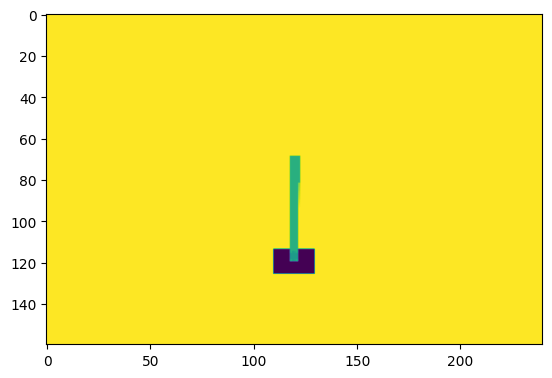

In [14]:
import matplotlib.pyplot as plt 
plt.imshow(ground_truth_gym_env.reset()[0][0][0])

In [24]:
if is_main:
    concept_list, processed_concepts = get_concepts(environment_string,"human_selected_binary",seed)
    num_concepts_selected = min(num_concepts_selected,len(concept_list))
    ground_truth_env, ground_truth_gym_env = get_environment(environment_string, None, seed,processed_concepts=processed_concepts)   
    model_name = "../../results/models/env={}_training={}_seed={}.zip".format(environment_string,gold_timesteps,seed)
    if os.path.exists(model_name):
        groundtruth_model = PPO.load(model_name)
    two_stage_env, two_stage_gym_env = get_environment(environment_string,concept_list,seed,concept_idx=list(range(len(concept_list))),processed_concepts=processed_concepts)
    two_stage_env.reset().shape

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

In [25]:
groundtruth_model.observation_space

Box(0, 255, (4, 84, 84), uint8)

In [26]:
model_name = "../../results/q_estimates/env={}_training={}_seed={}_selection={}_source={}.pkl".format(environment_string,gold_timesteps,seed,"q_value","human_selected_binary")
if os.path.exists(model_name):
    q_estimates = pickle.load(open(model_name,"rb"))

In [27]:
model_name = "../../results/models/concept_predictor_env={}_training={}_seed={}.pth".format(environment_string,100,seed)

height = width = 84

if environment_string == "mini_grid":
    num_frames = 1
else:
    num_frames = 4

if environment_string == "cart_pole":
    height = 160
    width = 240

device = 'cuda' if torch.cuda.is_available() else 'cpu'
if os.path.exists(model_name):
    concept_predictor = ConceptPredictorCNN(len(concept_list), num_frames=num_frames,height=height,width=width).to(device)
    concept_predictor.load_state_dict(torch.load(model_name, weights_only=True))
    concept_predictor.eval()

In [28]:
a,b = ground_truth_gym_env.reset()

In [29]:
np.mean(torch.sigmoid(concept_predictor(torch.tensor(a).float().cuda())[0]).detach().cpu().numpy() == np.array([c(b[0]['observation']) for c in concept_list]))

0.8333333333333334

In [61]:
concept_predictor, acc_list = train_concept_predictor(ground_truth_gym_env,groundtruth_model,concept_list,list(range(len(concept_list))),environment_string,epochs=25,max_episode_length=10_000)
acc_list 

ValueError: Error: Unexpected observation shape (4, 4, 84, 84) for Box environment, please use (1, 84, 84) or (n_env, 1, 84, 84) for the observation shape.

In [44]:
acc_list = evaluate_concept_predictor(concept_predictor,ground_truth_gym_env,groundtruth_model,concept_list,NUM_EPISODES=1)
acc_list.tolist()

Iteration 1000/10000
Iteration 2000/10000
Iteration 3000/10000
Iteration 4000/10000
Iteration 5000/10000
Iteration 6000/10000
Iteration 7000/10000
Iteration 8000/10000
Iteration 9000/10000
Iteration 10000/10000

✅ Collection complete!
X shape: (11678, 1, 84, 84), dtype: uint8, size: 78.6 MB
Y shape: (11678, 12), dtype: float32
Y contains 12 features per sample
Evaluation data - X shape: (11678, 1, 84, 84), Y shape: (11678, 44)
Evaluating concept predictor...

📊 Evaluation Results:
Overall F1 Score: 0.9429

Per-concept accuracy:
  ✅ Concept 0: 0.902
  ✅ Concept 1: 1.000
  ✅ Concept 2: 0.902
  ✅ Concept 3: 1.000
  ✅ Concept 4: 1.000
  ✅ Concept 5: 0.966
  ✅ Concept 6: 0.968
  ✅ Concept 7: 0.934
  ✅ Concept 8: 1.000
  ✅ Concept 9: 1.000
  ✅ Concept 10: 0.926
  ✅ Concept 11: 0.976
  ✅ Concept 12: 0.977
  ✅ Concept 13: 1.000
  ✅ Concept 14: 0.902
  ✅ Concept 15: 1.000
  ✅ Concept 16: 1.000
  ✅ Concept 17: 1.000
  ✅ Concept 18: 1.000
  ✅ Concept 19: 0.968
  ✅ Concept 20: 0.965
  ✅ Concept 21

[0.901695495804076,
 1.0,
 0.901695495804076,
 1.0,
 1.0,
 0.9662613461209111,
 0.9680595992464464,
 0.9343209453673574,
 1.0,
 1.0,
 0.9261003596506251,
 0.9759376605583148,
 0.9769652337729063,
 1.0,
 0.901695495804076,
 1.0,
 1.0,
 1.0,
 1.0,
 0.9678883370440143,
 0.9651481418051037,
 0.968659016954958,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 0.9521322144202774,
 0.9521322144202774,
 1.0,
 1.0,
 1.0,
 0.901695495804076,
 0.901695495804076,
 1.0,
 1.0,
 0.9677170748415824,
 0.9677170748415824,
 1.0,
 1.0,
 0.9328652166466861,
 0.9328652166466861]

In [25]:
two_stage_env, two_stage_gym_env = get_environment(environment_string,concept_list,seed,concept_idx=list(range(len(concept_list))),processed_concepts=processed_concepts)
model = train_ppo_model(two_stage_env,environment_string,policy="MlpPolicy",total_timesteps=training_timesteps,custom_name="{}_imperfect_concepts".format(environment_string))

approx_kl,██▆▄▄▃▃▃▃▃▁▃▂▂▄▃▂▃▂▂▃▃▅▄▄▃▂▃▃▅▁▅▁▃▁▂▂▂▂▂
clip_fraction,█▅▃▂▂▂▂▂▂▂▄▂▂▁▁▁▁▃▃▄▅▅▂▇▅▃▂▃▂▃▄▄▃▂▂▁▂▃▃▃
ema_norm_reward,▁▁▁▁▁▂▁▁▂▂▃▅▅▇█▇██▇▆▆▄▅▄▅▅▅▅▆▅▅▅▅▆▆▆▆▆▆▇
entropy_loss,▁▄▄▄▅▇▇▇▇▇██▇▆▆▆▇▇▇▇▇▇▇▇▆▇▇▇▇▇▇██████▇▇▇
episode_length_mean,▁▁▁▁▁▁▂▃▃▃▄█▅▆▇██▁█▅▄▇▃▃▃▄▃▄▄▄▅▃▄▄▄▄▆▅▄▄
episode_reward_max,▁▁▁▁▁▂▁▂▂▂▂▂▁▃▂▃▄▅█▇▇▆▇▄▇▄▆▅▇▃▃▃▃▃▅▄█▄▄▃
episode_reward_mean,▁▁▁▁▁▁▁▂▂▁▃▃▄▆▂▄▃█▅▆▄▇▅▅▄▄▃▅▅▃▅█▅▅▅▄▆█▅▆
episode_reward_min,▁▁▁▁▁▁▁▁▁▂▁▄█▂▄▇▃▇█▄█▇▆█▅▅▄▄▄▃▃▃▄▃▇▄▄▅▃▅
episodes_completed,▁▁▁▁▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇████
explained_variance,▅▅▇▇▇▄▆▃▃▂▇▇▆▆▁▁▁▂▂▁▁▁▁▁▁▁▁▁▁▂▂██▆▄▄▃▃▁▃
+1,...


In [26]:
two_stage_env, two_stage_gym_env = get_environment(environment_string,concept_list,seed,fast_predictor=concept_predictor,use_processed=True,concept_idx=list(range(len(concept_list))),processed_concepts=processed_concepts)
model = train_ppo_model(two_stage_env,environment_string,policy="MlpPolicy",total_timesteps=training_timesteps,custom_name="{}_imperfect_concepts".format(environment_string))

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

approx_kl,█▁▂▂▂▁▄▄▃▂▄▃▄▃▃▃▄▂▃▃▃▃▂▂▂▂▂▂▃▄▁▃▃▆▆▁▂▁▃▂
clip_fraction,▁▁▂▃▁▂▇▃▃▃▃▄▄▂▃▃▆▆▅▅▃▅▅██▃▆▁▂▅▁▄▅▆▆▁▁▁▁▂
ema_norm_reward,▁▁▁▁▁▂▂▂▃▃▃▃▃▃▃▃▄▄▅▅▃▄▆▇▆▆▆▇▆▆▆▇▆▇▇▇███▇
entropy_loss,▁▄▄▄▅▅▆▆▆▆▆▇██▇▇▇▇███▇█████▇▇▇▇▇▇▇▇▇██▇█
episode_length_mean,▁▁▁▁▁▁▂▂▂▃▃▃▂▃▃▂▃▂▄▅▃▆█▅▅▅██▃██████▄████
episode_reward_max,▁▁▁▁▁▂▁▂▃▂▃▂▃▃▂▃▃▃▃▃▆▃█▃▆█▄▄████▄███████
episode_reward_mean,▁▁▁▂▁▂▃▂▃▂▃▃▂▂▅▃▄▃▅▆█▃▃▃▇▅███▄▃▇████▅█▆█
episode_reward_min,▁▁▁▂▁▁▁▂▂▃▄▂▄▇▃▄▃▆▇███▆▃▄██▃▇█▃▄█████▆█▃
episodes_completed,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇████
explained_variance,▇▇▅▅▇▇▇▇▇▇▇█▇▇▇▇▇▇█▅▅▅███▇▇█▇▇▇▅▄▄▇▇▁▇▇█
+1,...


In [199]:
two_stage_env, two_stage_gym_env = get_environment(environment_string,concept_list,seed,processed_concepts=processed_concepts,concept_idx=list(range(len(concept_list))))
model = train_ppo_model(two_stage_env,environment_string,policy="MlpPolicy",total_timesteps=training_timesteps,custom_name="{}_perfect_concepts".format(environment_string))    


approx_kl,▁▁▂▂▄▂▂▁▂▂▂▄▄▄▃▃▃▄▄▄▄▂▄▇▇▃▃▄▄▄▄▄▅▅█▆▆▆██
clip_fraction,▁▁▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▁▂▂▂▄▂███▄▃▅▅▅▃▃▅▅▅▅█
ema_norm_reward,▂▁▁▁▁▁▁▁▁▂▁▂▂▂▂▃▂▂▄▃▃▄▄▅▅▆▆▅▅▇▆▆▇▇▇▇████
entropy_loss,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▃▃▄▄▄▄▄▄▄▄▅▅▅▆▆▆▆▆▇███
episode_length_mean,███████▃████▅█▅█▆▂███▃▂▂▃▂▃▅▃▃▃▂▂▅▂▂▂▂▂▁
episode_reward_max,▁▁▁▃▁▁▁▄▁▁▁█▁▃▁▅▅▁▁▆▁▄▄▁▅▅▇▁▃▄█████████▅
episode_reward_mean,▁▁▅▁▁▃▁▃▁▁▁▁▁▁▁▅▅▆▁▄▇▅▃▁▆▂▆▇█▇▇██▇██▇▇█▇
episode_reward_min,▆▁▃▁▁▁▁▁▆▃▁▁▁▄▁▁▇▅▅▁▁▁▁▅▇█▇▆▅██▇▇█▆▇█▇██
episodes_completed,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▇████
explained_variance,▁▁▅▅▅▄▅▅▅▅▅▅▅▅▄▆▇▆▇▇▇▇▇▇▇▇▇▇▇███████████
+1,...


In [198]:
train_ppo_model(vec_env,environment_string,policy="MlpPolicy",total_timesteps=training_timesteps,custom_name="{}_perfect_random".format(environment_string))        

approx_kl,▂▁▁▁▃▃▃▃▁▁▄▃▃▃▃▄▄▄▄█▅▃▃▅▅▅▅▅▆▅▄▄▅▅▅▆▆▆▆▆
clip_fraction,▁▁▁▁▁▁▁▁▁▁▁▃▁▁▃▃▄▄▄▄▁▁▂▂▃▃▃▄▄▄▃▄▃▅▅▅▅██▅
ema_norm_reward,▁▁▁▁▁▁▁▂▁▂▂▃▂▂▂▃▂▃▃▃▃▄▃▅▄▆▅▅▆▅▇▇▇▇▇█████
entropy_loss,▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▂▂▂▂▂▃▂▃▃▄▄▄▄▄▅▅▆▆▇▇▇▇██
episode_length_mean,████████▇██▄█▃▄▇▅▂▁▆▅▁▁▂▂█▃▃▁▃▂▂▁▂▂▁▁▁▂▁
episode_reward_max,▁▁▁▁▇▁▄▁▇▁▅▄▁▆▅█▁▆▇▆▆██▇█▇▁█████████████
episode_reward_mean,▁▁▁▁▁▁▁▁▁▄▁▄▄▄▅▂▂▆█▆▇▅██▆▇▇▆▇▇█▆█▆██▇▇█▇
episode_reward_min,▁▃▁▁▁▃▁▁▁▁▆▂▁▆▄▃▇▅▆▄▆▁▅▁▅▇▁▇▆▇▇▇▇▇██████
episodes_completed,▁▁▁▁▁▂▂▂▂▂▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▆▆▆▆▇▇▇▇▇█
explained_variance,▁▆▆▆▆▆▆▄▄▄▇▇▇▇▇▇▇████▇▇▇▇███████████████
+1,...


In [188]:
obs = [[1, 2, 2, 1, 3, 2, 2, 0, 0, 0, 0, 1], [1, 3, 3, 0, 0, 2, 1, 0, 0, 0, 0, 1], [1, 3, 2, 0, 0, 2, 1, 0, 0, 0, 0, 1], [1, 1, 2, 1, 3, 2, 1, 0, 0, 1, 0, 0], [1, 1, 3, 0, 0, 2, 1, 0, 0, 1, 0, 0], [1, 3, 0, 1, 2, 2, 1, 0, 0, 0, 0, 0], [1, 3, 3, 1, 2, 2, 1, 0, 0, 0, 0, 0], [1, 2, 3, 1, 3, 2, 1, 0, 0, 0, 0, 1]]
true = np.array([[c(o) for c in concept_list_old] for o in obs])
true.dtype


dtype('int64')